# Notebook 20: Deep Learning Mini Challenge



## 1. Define the prediction task and inspect the data
**Input:** 13 numeric chemical measurements per wine. **Target:** one of three cultivar classes. Begin with EDA: sample count, feature names and ranges, target counts, missing values, and feature distributions or correlations. State any data quality concerns before modeling.

Rows, features: (178, 13)
Missing values: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


Class counts:
 cultivar
0    59
1    71
2    48
Name: count, dtype: int64


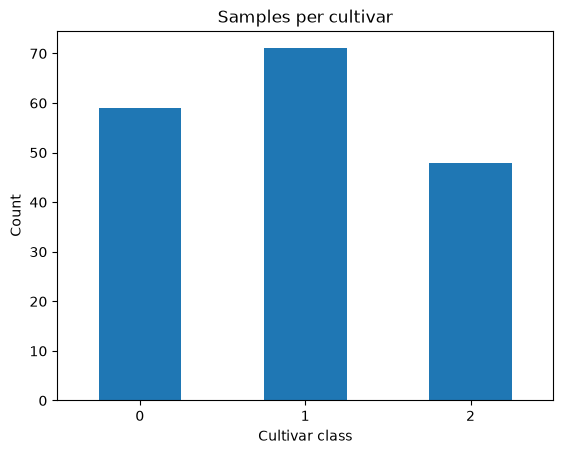

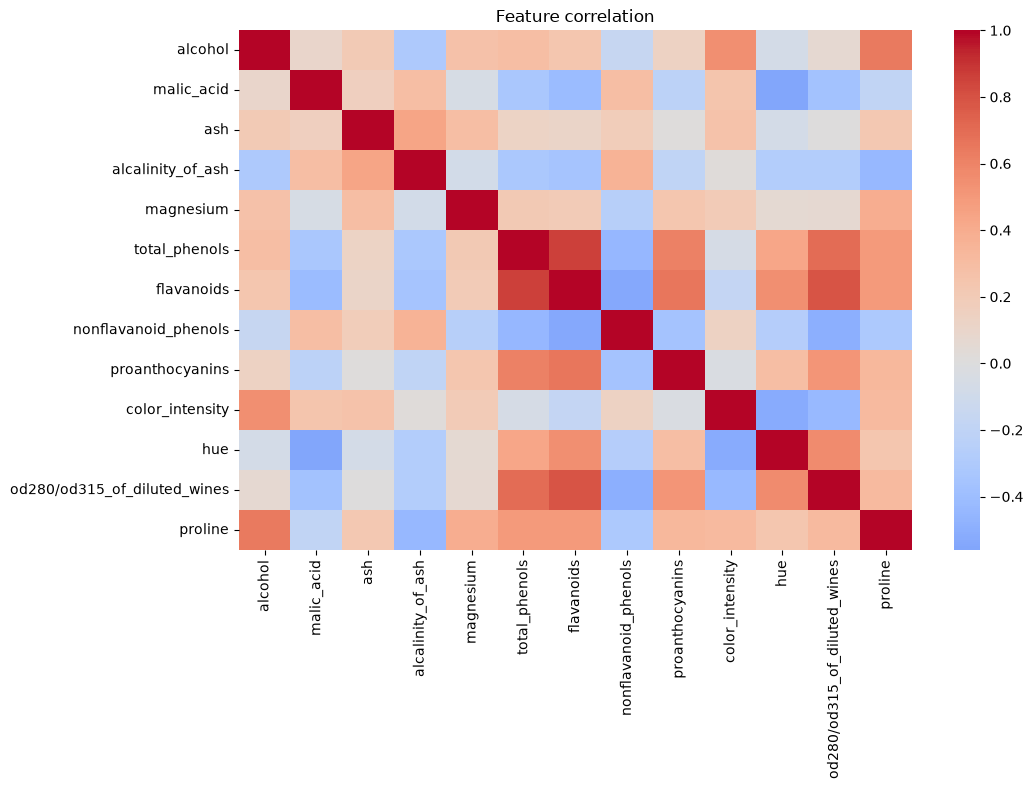

In [1]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 17
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = load_wine(as_frame=True)
X_df = dataset.data
y = dataset.target.to_numpy()
class_names = dataset.target_names
df = X_df.copy(); df['cultivar'] = dataset.target
print('Rows, features:', X_df.shape)
print('Missing values:', int(X_df.isna().sum().sum()))
display(df.head())
display(df.describe().T[['mean', 'std', 'min', 'max']])
print('Class counts:\n', df['cultivar'].value_counts().sort_index())
df['cultivar'].value_counts().sort_index().plot(kind='bar', rot=0, title='Samples per cultivar'); plt.xlabel('Cultivar class'); plt.ylabel('Count'); plt.show()
plt.figure(figsize=(11, 8)); sns.heatmap(X_df.corr(), cmap='coolwarm', center=0); plt.title('Feature correlation'); plt.tight_layout(); plt.show()

## 2. Prepare data and establish a baseline
Use stratified train/validation/test partitions so all three classes are represented. Fit the scaler using training features only. Train logistic regression as a traditional baseline; it is fast and helps determine whether the neural network's added complexity is worthwhile.

In [2]:
X_train_raw, X_temp, y_train, y_temp = train_test_split(X_df.to_numpy(), y, test_size=0.40, stratify=y, random_state=SEED)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
scaler = StandardScaler().fit(X_train_raw)
X_train_np = scaler.transform(X_train_raw).astype(np.float32)
X_val_np = scaler.transform(X_val_raw).astype(np.float32)
X_test_np = scaler.transform(X_test_raw).astype(np.float32)
print(f'Train={len(y_train)}, validation={len(y_val)}, test={len(y_test)}')
baseline = LogisticRegression(max_iter=2000, random_state=SEED)
baseline.fit(X_train_np, y_train)
baseline_val_pred = baseline.predict(X_val_np)
print(f'Logistic-regression validation accuracy: {accuracy_score(y_val, baseline_val_pred):.3f}')
X_train = torch.tensor(X_train_np); y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val_np); y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test = torch.tensor(X_test_np)

Train=106, validation=36, test=36
Logistic-regression validation accuracy: 1.000


## 3. Choose architecture and compare configurations
A compact multilayer perceptron is appropriate for this small dataset of fixed-length numeric features. It can learn nonlinear combinations while using far fewer resources than an image CNN. Compare a compact MLP against a wider, dropout-regularized MLP. Each configuration uses early stopping on validation loss and restores its best validation checkpoint.

In [3]:
configs = [
    {'name': 'Compact MLP', 'widths': [32], 'dropout': 0.0, 'lr': 0.01, 'batch_size': 16, 'weight_decay': 0.0},
    {'name': 'Regularized MLP', 'widths': [64, 32], 'dropout': 0.25, 'lr': 0.003, 'batch_size': 16, 'weight_decay': 1e-3},
]

def build_model(config):
    blocks = []; input_size = X_train.shape[1]
    for width in config['widths']:
        blocks.extend([nn.Linear(input_size, width), nn.ReLU()])
        if config['dropout'] > 0: blocks.append(nn.Dropout(config['dropout']))
        input_size = width
    blocks.append(nn.Linear(input_size, len(class_names)))
    return nn.Sequential(*blocks).to(device)

def fit_config(config, max_epochs=100, patience=12):
    torch.manual_seed(SEED)
    model = build_model(config)
    loader = DataLoader(TensorDataset(X_train, y_train_t), batch_size=config['batch_size'], shuffle=True, generator=torch.Generator().manual_seed(SEED))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    best_loss = float('inf'); best_state = None; stale_epochs = 0
    history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}
    for epoch in range(max_epochs):
        model.train()
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad(); loss = criterion(model(features), labels); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            train_logits = model(X_train.to(device)); val_logits = model(X_val.to(device))
            train_loss = criterion(train_logits, y_train_t.to(device)).item()
            val_loss = criterion(val_logits, y_val_t.to(device)).item()
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_accuracy'].append((train_logits.argmax(1).cpu() == y_train_t).float().mean().item())
        history['val_accuracy'].append((val_logits.argmax(1).cpu() == y_val_t).float().mean().item())
        if val_loss < best_loss - 1e-4:
            best_loss = val_loss; best_state = copy.deepcopy(model.state_dict()); stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience: break
    model.load_state_dict(best_state)
    return model, history

runs = []
for config in configs:
    model, history = fit_config(config)
    runs.append({'config': config, 'model': model, 'history': history})
    print(f"{config['name']}: best validation accuracy={max(history['val_accuracy']):.3f}; stopped at epoch {len(history['val_loss'])}")

Compact MLP: best validation accuracy=1.000; stopped at epoch 85
Regularized MLP: best validation accuracy=1.000; stopped at epoch 57


## 4. Compare training curves and select a final model
Compare training and validation curves. A rising validation loss while training loss falls suggests overfitting; both losses remaining high suggests underfitting or optimization trouble. Select using best validation accuracy, with validation loss as a tie-breaker, and state whether the improvement justifies the extra model complexity.

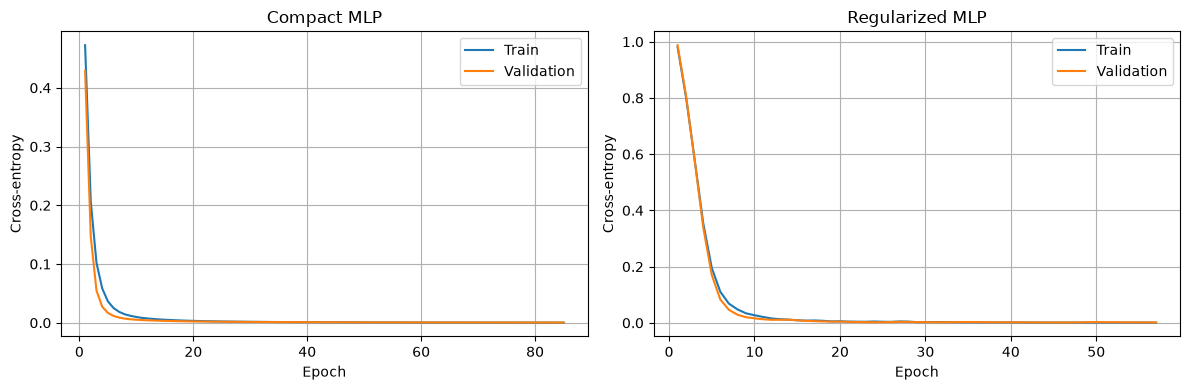

,Configuration,Architecture,Dropout,Weight decay,Learning rate,Batch size,Best validation accuracy,Minimum validation loss
0,Compact MLP,[32],0.00,0.000,0.010,16,1.0,0.000391
1,Regularized MLP,"[64, 32]",0.25,0.001,0.003,16,1.0,0.001207


Selected: Compact MLP


In [4]:
rows = []
fig, axes = plt.subplots(1, len(runs), figsize=(12, 4))
for ax, run in zip(np.atleast_1d(axes), runs):
    h = run['history']; epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='Train'); ax.plot(epochs, h['val_loss'], label='Validation')
    ax.set_title(run['config']['name']); ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy'); ax.grid(True); ax.legend()
    rows.append({'Configuration':run['config']['name'], 'Architecture':str(run['config']['widths']), 'Dropout':run['config']['dropout'],
                 'Weight decay':run['config']['weight_decay'], 'Learning rate':run['config']['lr'], 'Batch size':run['config']['batch_size'],
                 'Best validation accuracy':max(h['val_accuracy']), 'Minimum validation loss':min(h['val_loss'])})
plt.tight_layout(); plt.show()
results = pd.DataFrame(rows).sort_values(['Best validation accuracy', 'Minimum validation loss'], ascending=[False, True])
display(results)
best_run = max(runs, key=lambda r: (max(r['history']['val_accuracy']), -min(r['history']['val_loss'])))
final_model = best_run['model'].to(device).eval()
print('Selected:', best_run['config']['name'])

## 5. Final evaluation and error analysis
Evaluate the selected model exactly once on the held-out test set. Review per-class precision/recall and the confusion matrix. If mistakes cluster between two cultivars, identify which features or measurements might help distinguish them; do not infer causation from correlation alone.

Final test accuracy: 0.972
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      1.000     0.929     0.963        14
     class_2      0.909     1.000     0.952        10

    accuracy                          0.972        36
   macro avg      0.970     0.976     0.972        36
weighted avg      0.975     0.972     0.972        36



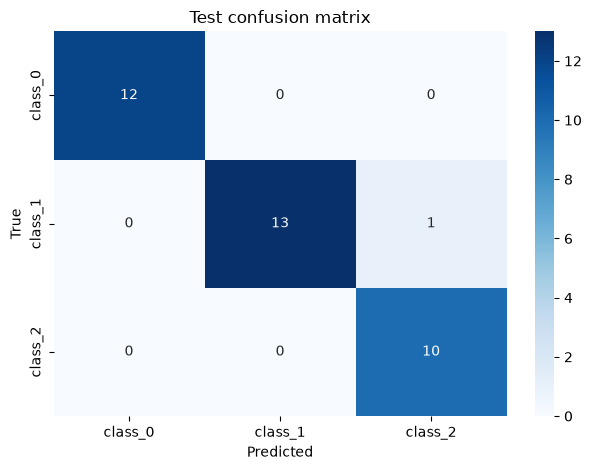

Misclassified 1 of 36 test samples.


,true_class,predicted_class
12,1,2


Compare this test result with the baseline validation result cautiously: they are different splits. If needed, calculate the baseline test result now for a matched test-set comparison.


In [5]:
with torch.no_grad():
    test_logits = final_model(X_test.to(device))
    test_pred = test_logits.argmax(1).cpu().numpy()
test_accuracy = accuracy_score(y_test, test_pred)
print(f'Final test accuracy: {test_accuracy:.3f}')
print(classification_report(y_test, test_pred, target_names=[str(name) for name in class_names], zero_division=0, digits=3))
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Test confusion matrix'); plt.tight_layout(); plt.show()
wrong = np.flatnonzero(test_pred != y_test)
print(f'Misclassified {len(wrong)} of {len(y_test)} test samples.')
if len(wrong):
    display(pd.DataFrame({'true_class': y_test[wrong], 'predicted_class': test_pred[wrong]}, index=wrong).head(10))
print('Compare this test result with the baseline validation result cautiously: they are different splits. If needed, calculate the baseline test result now for a matched test-set comparison.')

## 6. Limitations and future improvements
Write a short conclusion grounded in the results above. Address: whether the neural network beat logistic regression; which configuration was selected and why; likely error sources; and the limitations of a small, clean, laboratory dataset.

Possible future work: repeated stratified cross-validation, uncertainty estimates, calibration, targeted data-quality checks, feature selection, learning-rate scheduling, and external validation on wines collected under different conditions. Avoid claiming real-world deployment performance from this dataset alone.